In [1]:
import numpy as np
import pandas as pd
import torch

import sys
sys.path.append('../')
from utilities import binning_equal_q

In [2]:
def infer_fields(data, counts):
    
    fields = np.zeros([7,16])
    for pos in range(7):
        for color in range(16):
            fields[pos,color] = (counts*((data[:,pos] == color).astype('int'))).sum() 

    print(counts.sum(), fields.sum(1))

    fields7 = fields[6,:][fields[6,:] > 0]
    fields7 = torch.tensor(np.log(fields7 / fields7[0]))
    fields = fields[:6,:] / fields[:6,0][:,np.newaxis]
    fields = torch.tensor(np.log(fields))
    
    return fields, fields7

def sorted_log10p_vector_from_fields(fields, fields7):
    
    lengths = [torch.arange(16, dtype=torch.int8) for i in range(6)]
    lengths.append(torch.arange(11, dtype=torch.int8))
    all_seq = torch.cartesian_prod(*lengths)
    
    all_seq = all_seq.long()
    
    # generate p_vector
    p_vector = torch.zeros(11*16**6,dtype=torch.float32)

    for i in range(6):
        p_vector += fields[i,all_seq[:,i]]
        print(i)
    p_vector += fields7[all_seq[:,6]]
    
    p_vector = torch.exp(p_vector)
    
    Z = torch.exp(fields).sum(1).prod() * torch.exp(fields7).sum()
    
    p_vector /= Z
    print(p_vector.sum())
    
    return torch.log(p_vector).sort()[0] / np.log(10)

def log10q_vector_func(data, fields, fields7):
    
    # generate q_vector
    q_vector = torch.zeros(len(data))

    for i in range(6):
        q_vector += fields[i,data[:,i]]
        print(i)
    q_vector += fields7[data[:,6]]

    q_vector = torch.exp(q_vector)

    Z = torch.exp(fields).sum(1).prod() * torch.exp(fields7).sum()

    q_vector /= Z

    print(q_vector.sum())
    return np.log10(q_vector.numpy())

In [3]:
data = pd.read_csv('../data/Dalkara.csv',index_col=0).query('T0 > 0')

transform_dict = {np.unique(data['a7'])[i] : i for i in range(11)}
data['a7'] = data['a7'].replace(transform_dict)

data = data.sort_values('T0', ascending=False)

counts = data['T0'].to_numpy()
data = data.iloc[:,:7].to_numpy()

In [4]:
fields, fields7 = infer_fields(data, counts)

13653491 [13653491. 13653491. 13653491. 13653491. 13653491. 13653491. 13653491.]


In [5]:
sorted_log10p_vector = sorted_log10p_vector_from_fields(fields, fields7)

0
1
2
3
4
5
tensor(1.0000)


In [6]:
log10q_vector = log10q_vector_func(data, fields, fields7)
argsort = np.argsort(log10q_vector)
sorted_log10q_vector = log10q_vector[argsort][::-1]
counts = counts[argsort][::-1]

0
1
2
3
4
5
tensor(0.7839)


In [7]:
bins=200
df_bins = binning_equal_q(sorted_log10p_vector, sorted_log10q_vector, counts, bins=bins, writefolder='results_DalkaraT0_IM', step=1)
df_bins.to_csv('df_bins_Dalkara_IM_%dbins.csv'%bins)

0
tensor(184549375) tensor(184543116)
elements in the bin: 6259
nonzeros: 6260
1
tensor(184543116) tensor(184536855)
elements in the bin: 6261
nonzeros: 6260
2
tensor(184536855) tensor(184530595)
elements in the bin: 6260
nonzeros: 6260
3
tensor(184530595) tensor(184524336)
elements in the bin: 6259
nonzeros: 6260
4
tensor(184524336) tensor(184518075)
elements in the bin: 6261
nonzeros: 6260
5
tensor(184518075) tensor(184511814)
elements in the bin: 6261
nonzeros: 6260
6
tensor(184511814) tensor(184505553)
elements in the bin: 6261
nonzeros: 6260
7
tensor(184505553) tensor(184499291)
elements in the bin: 6262
nonzeros: 6260
8
tensor(184499291) tensor(184493028)
elements in the bin: 6263
nonzeros: 6260
9
tensor(184493028) tensor(184486761)
elements in the bin: 6267
nonzeros: 6260
10
tensor(184486761) tensor(184480494)
elements in the bin: 6267
nonzeros: 6260
11
tensor(184480494) tensor(184474217)
elements in the bin: 6277
nonzeros: 6260
12
tensor(184474217) tensor(184467940)
elements in

111
tensor(183322908) tensor(183297471)
elements in the bin: 25437
nonzeros: 6260
112
tensor(183297471) tensor(183271635)
elements in the bin: 25836
nonzeros: 6260
113
tensor(183271635) tensor(183245383)
elements in the bin: 26252
nonzeros: 6260
114
tensor(183245383) tensor(183218615)
elements in the bin: 26768
nonzeros: 6260
115
tensor(183218615) tensor(183191485)
elements in the bin: 27130
nonzeros: 6260
116
tensor(183191485) tensor(183163348)
elements in the bin: 28137
nonzeros: 6260
117
tensor(183163348) tensor(183134517)
elements in the bin: 28831
nonzeros: 6260
118
tensor(183134517) tensor(183105037)
elements in the bin: 29480
nonzeros: 6260
119
tensor(183105037) tensor(183074216)
elements in the bin: 30821
nonzeros: 6260
120
tensor(183074216) tensor(183042845)
elements in the bin: 31371
nonzeros: 6260
121
tensor(183042845) tensor(183010916)
elements in the bin: 31929
nonzeros: 6260
122
tensor(183010916) tensor(182977904)
elements in the bin: 33012
nonzeros: 6260
123
tensor(18297

In [8]:
df_bins

,edge_sx,edge_dx,n_lambdas,n_lambdas_inferred_aritm,n_lambdas_inferred_geo,n_nonzeros,mean_aritm_lambda,mean_geom_lambda,mean_lambda,var_uniform_lambda,var_lambda,mean_count,var_count
0,-2.627385,-4.839916,6259,2.152253e+02,1.382876e+03,6260,16198.804359,2521.117826,555.1352,8.534841e+07,657661.6,557.020770,609038.834526
1,-4.839916,-5.084938,6261,6.094015e+03,6.338094e+03,6260,154.836012,148.873297,146.28688,6.036440e+02,585.7088,150.706437,2480.659388
2,-5.084938,-5.229666,6260,6.311440e+03,6.399258e+03,6260,96.370246,95.047742,94.5474,8.438366e+01,83.62515,97.162141,993.061091
3,-5.229666,-5.339270,6259,6.390466e+03,6.441411e+03,6260,71.486498,70.921112,70.804276,2.683842e+01,26.67597,72.988017,638.832098
4,-5.339270,-5.426815,6261,6.282811e+03,6.314749e+03,6260,56.807220,56.519898,56.461796,1.085376e+01,10.686847,57.005111,434.507880
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-9.245949,-9.377131,3217104,3.132203e+06,3.167993e+06,6260,0.006740,0.006664,0.006673489,3.401766e-07,3.3878982e-07,0.006562,0.035416
196,-9.377131,-9.540408,4426829,4.306116e+06,4.382422e+06,6260,0.004832,0.004748,0.004759599,2.686345e-07,2.6712985e-07,0.004700,0.025207
197,-9.540408,-9.761549,6759049,6.704065e+06,6.922520e+06,6260,0.003149,0.003050,0.0030660054,2.053439e-07,2.0323867e-07,0.003124,0.016766
198,-9.761549,-10.132176,13241224,1.264599e+07,1.381482e+07,6260,0.001686,0.001543,0.0015705746,1.534924e-07,1.4968253e-07,0.001610,0.008797


## write down F

In [9]:
df_bins = pd.read_csv('df_bins_Dalkara_IM_200bins.csv',index_col=0)
F_vec = np.zeros(2)
F = ((df_bins['var_count'] - df_bins['var_lambda']) / df_bins['mean_count']).to_numpy()
F = F[F > 0]
F_vec[0] = F.mean()
F_vec[1] = F.std()
np.savetxt('F_Dalkara.csv',F_vec,delimiter=',')
F_vec

array([5.55033231, 0.68464049])

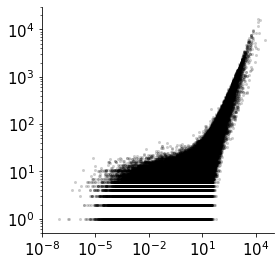

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3.8),facecolor='white')
ax = plt.subplot(111)

x = (10**sorted_log10q_vector)*counts.sum()
y = counts
plt.scatter(x,y, marker='.', color='black', alpha=0.2, linewidth=0)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.spines[['top','right']].set_visible(False)
plt.ylim(5e-1,3e4)
plt.xlim(1e-8,1e5)

plt.tight_layout()
plt.savefig('../fig1_paper/Dalkara_empirical_vs_predicted.png', dpi=1200)

In [14]:
sorted_log10q_vector

array([ -2.627385 ,  -2.9193623,  -2.9806907, ..., -13.592919 ,
       -13.649796 , -14.147951 ], dtype=float32)